<a href="https://colab.research.google.com/github/surkovaolga2005-png/python-ai-surkoa-olga/blob/main/notebooks/week3_population_dynamics_fix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# подключаем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# удаляем старую копию репозитория, если она уже была загружена
!rm -rf python-ai-surkoa-olga

# клонируем репозиторий из github
!git clone https://github.com/surkovaolga2005-png/python-ai-surkoa-olga

Cloning into 'python-ai-surkoa-olga'...
remote: Enumerating objects: 403, done.
remote: Counting objects: 100% (197/197), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 403 (delta 166), reused 111 (delta 111), pack-reused 206 (from 2)
Receiving objects: 100% (403/403), 2.82 MiB | 11.38 MiB/s, done.
Resolving deltas: 100% (228/228), done.


In [ ]:
# читаем файл с населением по годам
population_path = "python-ai-surkoa-olga/data/population.csv"

population_df = pd.read_csv(population_path)

population_df.head()

,country,countryLabel,population,pointInTime,year
0,http://www.wikidata.org/entity/Q408,Австралия,22637127,2012-03-01T00:00:00Z,2012.0
1,http://www.wikidata.org/entity/Q408,Австралия,22920450,2012-12-01T00:00:00Z,2012.0
2,http://www.wikidata.org/entity/Q408,Австралия,22826041,2012-09-01T00:00:00Z,2012.0
3,http://www.wikidata.org/entity/Q408,Австралия,22723904,2012-06-01T00:00:00Z,2012.0
4,http://www.wikidata.org/entity/Q408,Австралия,23035199,2013-03-01T00:00:00Z,2013.0


In [ ]:
# переименовываем столбцы
population_df = population_df.rename(columns={
    "country": "country_id",
    "countryLabel": "country",
    "population": "population",
    "pointInTime": "point_in_time",
    "year": "year"
})

# приводим население и год к числовому типу
population_df["population"] = pd.to_numeric(population_df["population"], errors="coerce")
population_df["year"] = pd.to_numeric(population_df["year"], errors="coerce")

population_df.head()

,country_id,country,population,point_in_time,year
0,http://www.wikidata.org/entity/Q408,Австралия,22637127,2012-03-01T00:00:00Z,2012.0
1,http://www.wikidata.org/entity/Q408,Австралия,22920450,2012-12-01T00:00:00Z,2012.0
2,http://www.wikidata.org/entity/Q408,Австралия,22826041,2012-09-01T00:00:00Z,2012.0
3,http://www.wikidata.org/entity/Q408,Австралия,22723904,2012-06-01T00:00:00Z,2012.0
4,http://www.wikidata.org/entity/Q408,Австралия,23035199,2013-03-01T00:00:00Z,2013.0


In [ ]:
# удаляем строки без года и населения
population_clean = population_df.dropna(subset=["year", "population"]).copy()

# переводим год в целое число
population_clean["year"] = population_clean["year"].astype(int)

# агрегируем данные, чтобы для одной страны и одного года была одна строка
pop_yearly = (
    population_clean
    .groupby(["country_id", "country", "year"], as_index=False)["population"]
    .max()
)

pop_yearly.head()

,country_id,country,year,population
0,http://www.wikidata.org/entity/Q1000,Габон,1960,498823
1,http://www.wikidata.org/entity/Q1000,Габон,1961,503762
2,http://www.wikidata.org/entity/Q1000,Габон,1962,509348
3,http://www.wikidata.org/entity/Q1000,Габон,1963,515762
4,http://www.wikidata.org/entity/Q1000,Габон,1964,523236


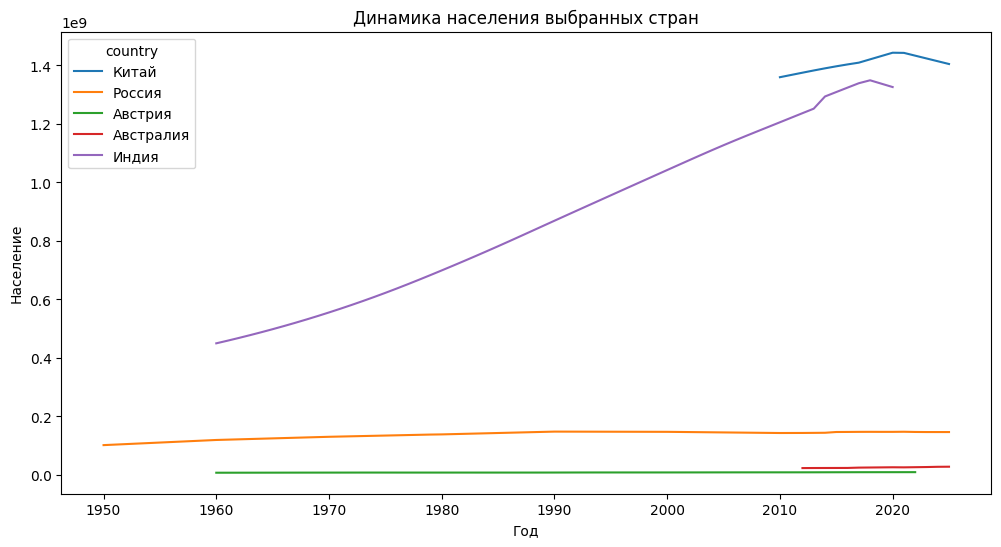

In [ ]:
# выбираем страны для исходного графика
selected_countries = ["Китай", "Россия", "Австрия", "Австралия", "Индия"]

population_selected = pop_yearly[
    pop_yearly["country"].isin(selected_countries)
]

# строим исходный график
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=population_selected,
    x="year",
    y="population",
    hue="country"
)

plt.title("Динамика населения выбранных стран")
plt.xlabel("Год")
plt.ylabel("Население")
plt.show()

## Замечания к исходному графику

В исходном графике страны с очень большим населением и страны с небольшим населением были показаны на одной шкале. Из-за этого линии Китая и Индии были хорошо видны, а линии России, Австрии и Австралии выглядели почти плоскими.

Также шкала слева отображалась в формате `1e9`, что не очень удобно для восприятия. Лучше явно подписать единицы измерения: миллиарды человек для крупных стран и миллионы человек для остальных стран.

Кроме того, для России корректнее ограничить временной период с 1991 года, чтобы рассматривать именно современную Россию, а не данные, которые могут относиться к СССР или более ранним периодам.

Поэтому исправленный график должен:
1. использовать две шкалы;
2. слева показывать Китай и Индию в миллиардах человек;
3. справа показывать Россию, Австрию и Австралию в миллионах человек;
4. начинать временную шкалу с 1991 года;
5. иметь понятные подписи осей.

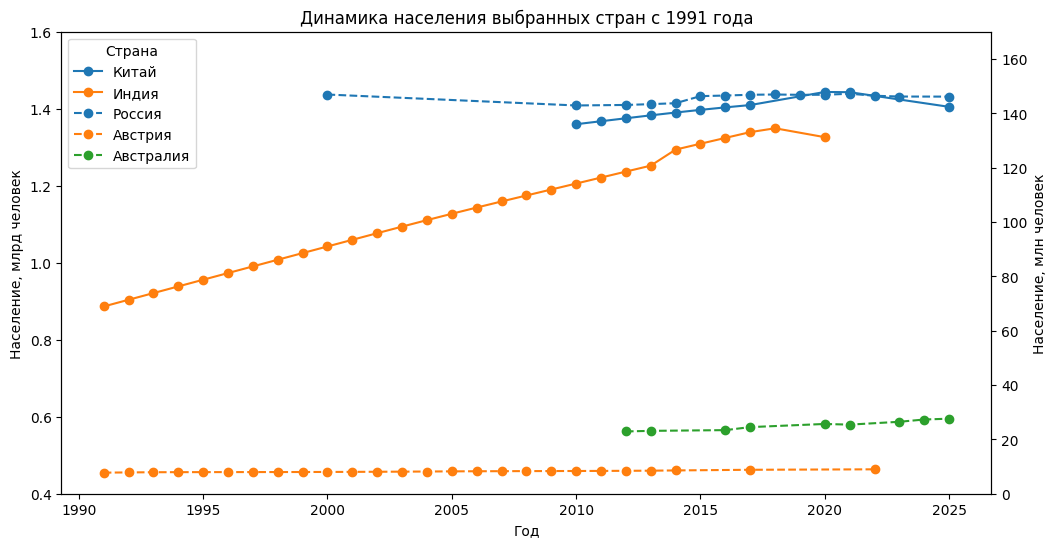

In [ ]:
# выбираем страны для исправленного графика
large_countries = ["Китай", "Индия"]
small_countries = ["Россия", "Австрия", "Австралия"]

# оставляем данные только с 1991 года
population_after_1991 = pop_yearly[pop_yearly["year"] >= 1991].copy()

# делим данные на две группы
large_data = population_after_1991[
    population_after_1991["country"].isin(large_countries)
]

small_data = population_after_1991[
    population_after_1991["country"].isin(small_countries)
]

# создаем график с двумя шкалами
fig, ax_left = plt.subplots(figsize=(12, 6))

# левая шкала для Китая и Индии
for country in large_countries:
    country_data = large_data[large_data["country"] == country].sort_values("year")
    ax_left.plot(
        country_data["year"],
        country_data["population"] / 1_000_000_000,
        marker="o",
        label=country
    )

ax_left.set_xlabel("Год")
ax_left.set_ylabel("Население, млрд человек")
ax_left.set_ylim(0.4, 1.6)

# правая шкала для России, Австрии и Австралии
ax_right = ax_left.twinx()

for country in small_countries:
    country_data = small_data[small_data["country"] == country].sort_values("year")
    ax_right.plot(
        country_data["year"],
        country_data["population"] / 1_000_000,
        marker="o",
        linestyle="--",
        label=country
    )

ax_right.set_ylabel("Население, млн человек")
ax_right.set_ylim(0, 170)

# объединяем легенды с двух осей
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()

ax_left.legend(
    lines_left + lines_right,
    labels_left + labels_right,
    title="Страна",
    loc="upper left"
)

plt.title("Динамика населения выбранных стран с 1991 года")
plt.show()

## Вывод

Исправленный график стал нагляднее, потому что страны разделены по масштабу населения.

Китай и Индия показаны по левой шкале в миллиардах человек. Это позволяет сравнить две самые крупные страны между собой.

Россия, Австрия и Австралия показаны по правой шкале в миллионах человек. Благодаря этому их линии больше не выглядят плоскими, и можно увидеть изменения населения внутри этой группы стран.

Временная шкала начинается с 1991 года, поэтому для России рассматривается современный период.